Optimization + Bias-Variance: Lab

> Add blockquote



In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)


train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


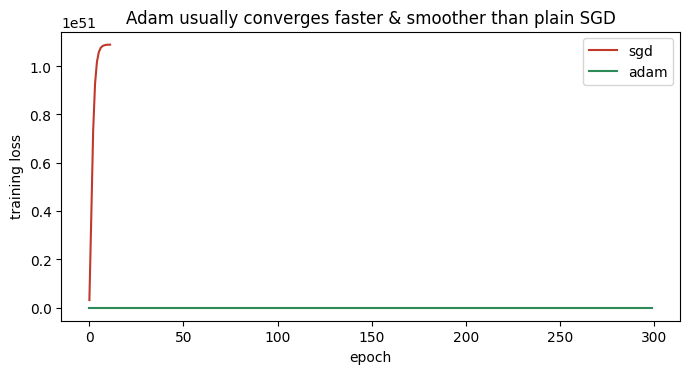

In [ ]:

# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


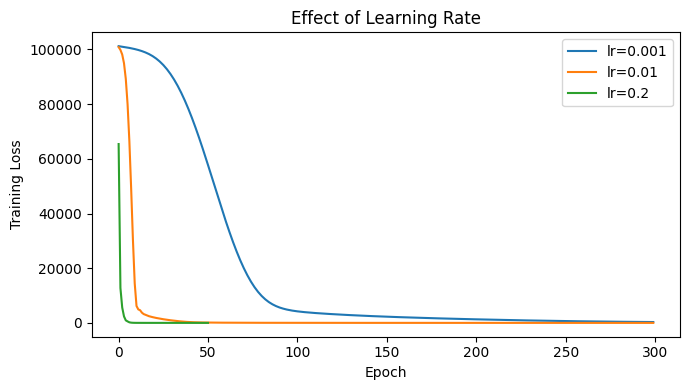

In [ ]:
# 1-2. three learning rates, plotted

fig, ax = plt.subplots(figsize=(7,4))

learning_rates = [0.001, 0.01, 0.2]

for lr in learning_rates:

    nn = MLPRegressor(
        hidden_layer_sizes=(32,16),
        solver='adam',
        learning_rate_init=lr,
        max_iter=300,
        random_state=0
    )

    nn.fit(Xtr, y_train)

    ax.plot(
        nn.loss_curve_,
        label=f'lr={lr}'
    )

ax.set_xlabel('Epoch')

ax.set_ylabel('Training Loss')

ax.set_title('Effect of Learning Rate')

ax.legend()

plt.tight_layout()

plt.show()



# 3. too slow / good / unstable: ...   (comment)
# lr=0.0001 : too slow because the updates are tiny.

# lr=0.01 : good because the model converges quickly and smoothly.

# lr = 0.2 : relatively aggressive; it may still converge with Adam,
# but can become unstable depending on the dataset.


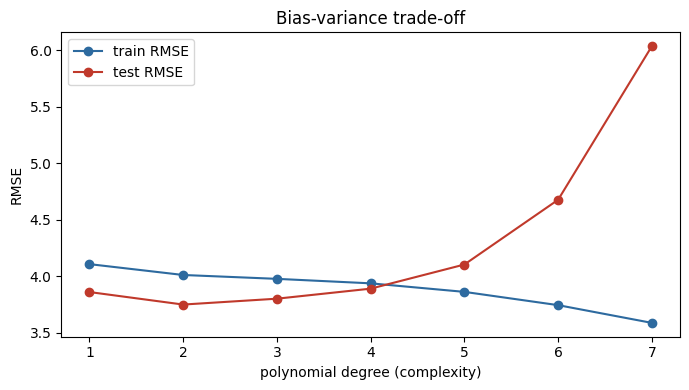

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [ ]:

# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

In [ ]:

# 1. best degree by test RMSE
best_degree = degrees[np.argmin(te_err)]

best_rmse = min(te_err)

print("Best degree:", best_degree)

print("Best test RMSE:", round(best_rmse,3))
# YOUR CODE HERE

# 2. label the two ends: ...   (comm

Best degree: 2
Best test RMSE: 3.751


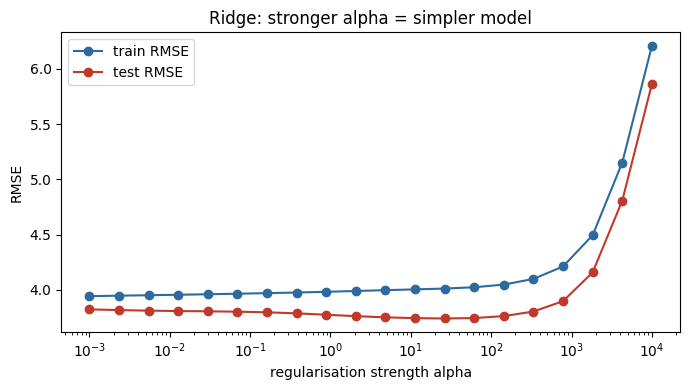

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. scaled degree-1 Lasso

lasso_pipe = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.5)
)

lasso_pipe.fit(X_train, y_train)

# 2. print coefficients

coefs = pd.Series(
    lasso_pipe.named_steps['lasso'].coef_,
    index=df.columns[:-1] # Corrected: use feature names from df
)

print(coefs)
dropped = coefs[coefs == 0].index.tolist()

print("Dropped features:", dropped)

AT   -16.973951
V     -2.925827
AP     0.000000
RH     0.000000
dtype: float64
Dropped features: ['AP', 'RH']


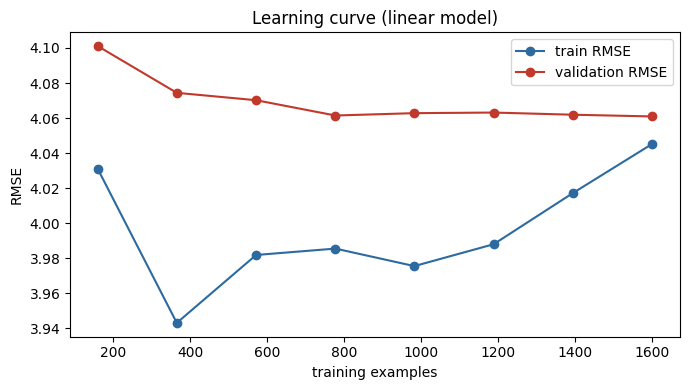

Both errors high and close => more bias-limited than variance-limited here.


In [ ]:

# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')

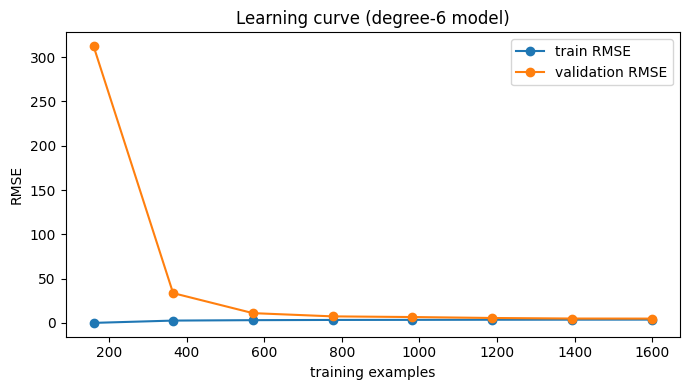

In [ ]:
# 1. learning curve for a degree-6 pipeline

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

deg6 = make_pipeline(
    PolynomialFeatures(6),
    StandardScaler(),
    LinearRegression()
)

sizes, train_sc, val_sc = learning_curve(
    deg6,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8)
)

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(
    sizes,
    -train_sc.mean(axis=1),
    'o-',
    label='train RMSE'
)

ax.plot(
    sizes,
    -val_sc.mean(axis=1),
    'o-',
    label='validation RMSE'
)

ax.set_xlabel('training examples')
ax.set_ylabel('RMSE')
ax.set_title('Learning curve (degree-6 model)')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------- # 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION # ----------------------------------------------------------- from sklearn.model_selection import cross_val_score best = None for d in [1, 2, 3]: for a in [0.1, 1, 10, 100]: m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a)) score = -cross_val_score(m, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean() if best is None or score < best[0]: best = (score, d, a) print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

In [ ]:
# 1. fit best config, score on test

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Re-calculate 'best' for self-contained execution
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)

best_degree = best[1]
best_alpha = best[2]

best_model = make_pipeline(
    PolynomialFeatures(best_degree),
    StandardScaler(),
    Ridge(alpha=best_alpha)
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

test_rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("Best model test RMSE:", round(test_rmse,2))

Best model test RMSE: 3.72


In [ ]:
baseline = LinearRegression()

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_rmse = mean_squared_error(
    y_test,
    baseline_pred
) ** 0.5

print("Baseline RMSE:", round(baseline_rmse,2))

Baseline RMSE: 3.86


Supervised Learning Foundations: Lab

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_maintenance(csv_path="machine_maintenance.csv", seed=14, verbose=False):
    """Predictive maintenance: predict whether a machine will FAIL from its
    operating conditions. A realistic, imbalanced binary-classification problem —
    perfect for the full supervised workflow and comparing model families.

    Features:
      machine_type        product quality variant (L / M / H)
      air_temperature_k    ambient temperature (K)
      process_temperature_k process temperature (K)
      rotational_speed_rpm spindle speed (rpm)
      torque_nm            torque (Nm)
      tool_wear_min        cumulative tool wear (minutes)
    Target:
      machine_failure      1 = failed, 0 = healthy
    """
    rng = np.random.default_rng(seed)
    N = 3000
    mtype = rng.choice(["L", "M", "H"], N, p=[0.50, 0.30, 0.20])
    air = rng.normal(300, 2.0, N)
    process = air + 10 + rng.normal(0, 1.0, N)
    speed = np.clip(rng.normal(1540, 170, N), 1168, 2886).round().astype(int)
    torque = np.clip(rng.normal(40, 10, N), 3, 77).round(1)
    wear = rng.uniform(0, 253, N).round().astype(int)
    type_eff = np.select([mtype == "L", mtype == "M", mtype == "H"], [0.6, 0.0, -0.5])

    # failure risk: worn tools, high torque, an overstrain interaction, and poor heat dissipation
    heat_bad = ((process - air) < 8.6).astype(float)
    z = (-5.2
         + 0.012 * wear
         + 0.06 * (torque - 40)
         + 4.0e-4 * wear * (torque - 40)
         + 0.7 * heat_bad
         + type_eff)
    p = 1 / (1 + np.exp(-z))
    failure = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "machine_type": mtype,
        "air_temperature_k": air.round(1),
        "process_temperature_k": process.round(1),
        "rotational_speed_rpm": speed,
        "torque_nm": torque,
        "tool_wear_min": wear,
        "machine_failure": failure,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("maintenance:", df.shape)
        print("failure rate:", round(df.machine_failure.mean(), 3))
        print("failures by type:\n",
              df.groupby("machine_type")["machine_failure"].mean().round(3).to_string())
    return df

if not os.path.exists('machine_maintenance.csv'):
    build_maintenance(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_maintenance.csv')
print('shape:', df.shape)
print('failure rate:', round(df['machine_failure'].mean(), 3))
df.head(3)

shape: (3000, 7)
failure rate: 0.074


,machine_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,H,298.8,309.2,1704,29.4,224,0
1,L,299.2,312.4,1611,36.9,178,0
2,M,301.8,310.4,1243,23.6,27,0


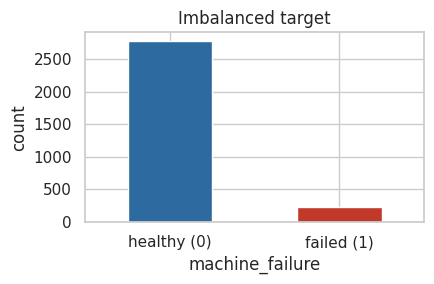

X: (3000, 6) | classification, 2 classes
Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. TARGET BALANCE + FEATURES / TARGET
# -----------------------------------------------------------
ax = df['machine_failure'].value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], figsize=(4.5, 3))
ax.set_xticklabels(['healthy (0)', 'failed (1)'], rotation=0); ax.set_ylabel('count')
ax.set_title('Imbalanced target'); plt.tight_layout(); plt.show()

y = df['machine_failure']
X = df.drop(columns='machine_failure')
print('X:', X.shape, '| classification, 2 classes')
print('Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.')

In [ ]:

# -----------------------------------------------------------
# 🔹 2A. PREPROCESS (encode + scale) + A FIRST MODEL
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num = X.select_dtypes('number').columns.tolist()
cat = ['machine_type']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), cat)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

clf = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)                 # FIT — learn from training data
preds = clf.predict(X_test)               # PREDICT — apply to unseen data
print('score (accuracy):', round(clf.score(X_test, y_test), 3))

score (accuracy): 0.736


In [ ]:
# 1. always-healthy accuracy
always_healthy_accuracy = (y_test == 0).sum() / len(y_test)
print(f'Always-healthy accuracy: {always_healthy_accuracy:.3f}')

# 2-3. compare & explain: ...   (comment)

Always-healthy accuracy: 0.925


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN FOUR FAMILIES, COMPARE ON TEST
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'kNN': KNeighborsClassifier(n_neighbors=15),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
}
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name,
                 'F1': f1_score(y_test, pipe.predict(X_test)),
                 'ROC_AUC': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)


                 F1  ROC_AUC
model                       
LogReg        0.322    0.870
DecisionTree  0.252    0.736
kNN           0.159    0.810
RandomForest  0.094    0.838


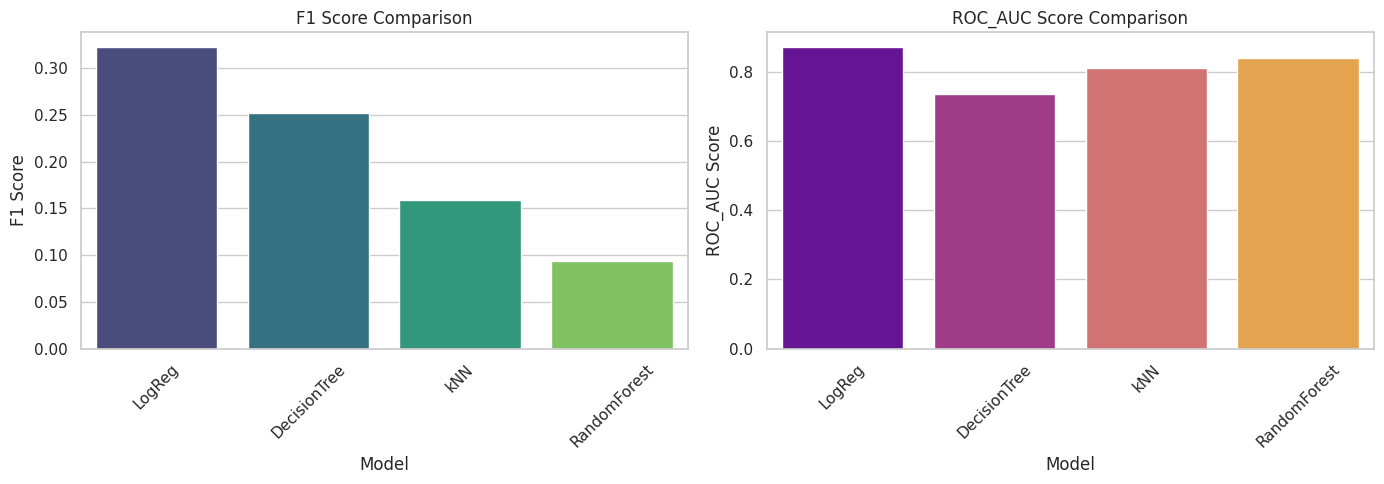

In [ ]:
# 1. bar chart of the comparison
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot F1 scores
sns.barplot(x=results.index, y='F1', data=results, ax=axes[0], palette='viridis', hue=results.index, legend=False)
axes[0].set_title('F1 Score Comparison')
axes[0].set_ylabel('F1 Score')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)

# Plot ROC_AUC scores
sns.barplot(x=results.index, y='ROC_AUC', data=results, ax=axes[1], palette='plasma', hue=results.index, legend=False)
axes[1].set_title('ROC_AUC Score Comparison')
axes[1].set_ylabel('ROC_AUC Score')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2. best model & margin:
# The best model is Logistic Regression, with an F1 score of 0.322 and ROC_AUC of 0.870.
# It shows a clear margin over DecisionTree, kNN, and RandomForest on both metrics, especially F1 score.

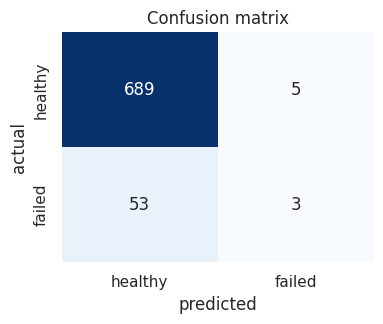

              precision    recall  f1-score   support

           0      0.929     0.993     0.960       694
           1      0.375     0.054     0.094        56

    accuracy                          0.923       750
   macro avg      0.652     0.523     0.527       750
weighted avg      0.887     0.923     0.895       750



In [ ]:
# -----------------------------------------------------------
# 🔹 4A. CONFUSION MATRIX + FULL REPORT (random forest)
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
rf = Pipeline([('prep', pre), ('model', RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
cm = confusion_matrix(y_test, rf.predict(X_test))
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failed'], yticklabels=['healthy', 'failed'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()
print(classification_report(y_test, rf.predict(X_test), digits=3))

In [ ]:
proba_rf = rf.predict_proba(X_test)[:, 1]
# 1-2. read precision/recall for the failed class; which matters more? ...   (comment)

# 3. lower the threshold to 0.3 and recompute recall
from sklearn.metrics import recall_score

new_threshold = 0.3
new_predictions_rf = (proba_rf >= new_threshold).astype(int)

recall_at_0_3 = recall_score(y_test, new_predictions_rf)
print(f'Recall for failed class (threshold=0.3): {recall_at_0_3:.3f}')

Recall for failed class (threshold=0.3): 0.250


In [ ]:

# -----------------------------------------------------------
# 🔹 5A. 5-FOLD ROC-AUC (mean +/- std) PER MODEL
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    s = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
    print(f'{name:14s} ROC-AUC {s.mean():.3f} +/- {s.std():.3f}')

LogReg         ROC-AUC 0.857 +/- 0.016
DecisionTree   ROC-AUC 0.780 +/- 0.052
kNN            ROC-AUC 0.770 +/- 0.021
RandomForest   ROC-AUC 0.808 +/- 0.015


In [ ]:
# 1. per-fold F1 for the random forest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Get the Random Forest model from the 'models' dictionary
rf_model = models['RandomForest']

# Create a pipeline for the Random Forest model
rf_pipe = Pipeline([('prep', pre), ('model', rf_model)])

# Calculate per-fold F1 scores using cross-validation
f1_scores = cross_val_score(rf_pipe, X, y, cv=5, scoring='f1')

print(f'Random Forest per-fold F1 scores: {f1_scores}')
print(f'Mean F1: {f1_scores.mean():.3f} +/- {f1_scores.std():.3f}')

# 2. fold spread & why CV matters: ...   (comment)

Random Forest per-fold F1 scores: [0.28571429 0.         0.19230769 0.08510638 0.16      ]
Mean F1: 0.145 +/- 0.097


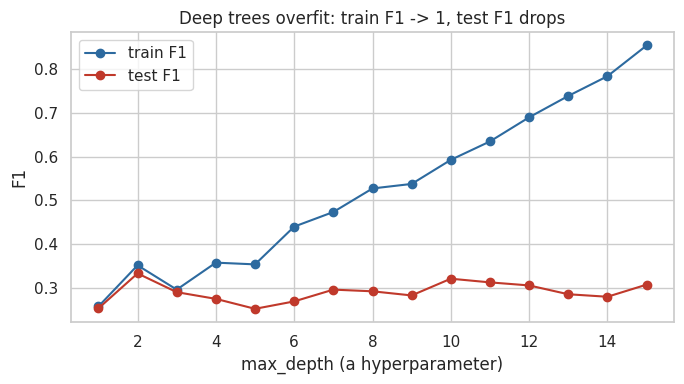

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. A HYPERPARAMETER (tree depth) DRIVES OVER/UNDERFIT
# -----------------------------------------------------------
depths = range(1, 16)
tr, te = [], []
for d in depths:
    p = Pipeline([('prep', pre), ('model', DecisionTreeClassifier(
        max_depth=d, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, p.predict(X_train)))
    te.append(f1_score(y_test, p.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train F1', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test F1', color='#C0392B')
ax.set_xlabel('max_depth (a hyperparameter)'); ax.set_ylabel('F1'); ax.legend()
ax.set_title('Deep trees overfit: train F1 -> 1, test F1 drops'); plt.tight_layout(); plt.show()

In [ ]:
# 1. best max_depth by test F1
best_test_f1_idx = np.argmax(te)
best_max_depth = depths[best_test_f1_idx]
highest_test_f1 = te[best_test_f1_idx]

print(f'Best max_depth by test F1: {best_max_depth}')
print(f'Highest test F1 score: {highest_test_f1:.3f}')

# 2. parameter vs hyperparameter here: ...   (comment)

Best max_depth by test F1: 2
Highest test F1 score: 0.333


In [ ]:
display(results.loc[['RandomForest', 'DecisionTree']])

,F1,ROC_AUC
model,,
RandomForest,0.094,0.838
DecisionTree,0.252,0.736


Regression (Part 1): Lab